# Annotated autoencoder analysis

This notebook loads the trained annotated autoencoder through the workspace API, performs one explicit full-image inference pass, and reuses the prepared cache for every analysis below.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import os
from pathlib import Path

# seting global dir
current_path = Path.cwd().resolve()
repository_root = next(
    path for path in (current_path, *current_path.parents)
    if (path / 'pyproject.toml').is_file()
)
os.chdir(repository_root)
repository_root

PosixPath('/home/maxi7524/repositories/MSIAutoEncoderWrapper')

## Configuration

Only the workspace, default image, and saved model identify the experiment. The wrapper resolves paths relative to the workspace and uses the default image whenever an explicit image is omitted.

In [2]:
PROJECT_PATH = 'workspace'
DEFAULT_IMAGE = 'kidney-pilot-v2'
MODEL_NAME = 'kidney-annotation-autoencoder'

BATCH_SIZE = 8
DIAGNOSTIC_SPECTRA = 128
TSNE_ENABLED = False
RANDOM_SEED = 1912

## Load the image context and trained model

The context setters intentionally omit an image argument. They register their strategies for `DEFAULT_IMAGE`, so no manual active-image switching or direct dataset paths are needed.

In [ ]:
from msi_autoencoder_wrapper import MSIAutoEncoderWrapper


wrapper = MSIAutoEncoderWrapper(project_path=PROJECT_PATH)
wrapper.workspace.set_default_image_path(DEFAULT_IMAGE)

config = wrapper.load_configuration(
    model_name="kidney-annotation-autoencoder",
)

print('Device:', wrapper.device)
print('Default image:', wrapper.workspace.default_img_name)
print('Spectra:', wrapper.active_context.reader.GetNumberOfSpectra())
print('Binner depth:', wrapper.active_context.binner.GetXAxisDepth())


print('Model:', MODEL_NAME)
print('Dataset samples:', len(wrapper.active_dataset))
print('Target specifications:', wrapper.active_dataset.target_specs)
print('Head bindings:', wrapper.active_model)

2026-07-30 02:14:27,365 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.
2026-07-30 02:14:27,367 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 15 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.
2026-07-30 02:14:27,369 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.
2026-07-30 02:14:27,371 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 21 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.
2026-07-30 02:14:27,385 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 9 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.
2026-07-30 02

## Calculate latent representations and prepare the analysis cache

`prepare()` is the only complete model traversal in this notebook. It calculates latent vectors, reconstructions, head logits, targets, and lightweight reconstruction statistics together. Calling `autoencoder.transform()` first would encode the same image twice.

In [4]:
from msi_autoencoder_wrapper.analysis import AutoencoderAnalysis
from msi_autoencoder_wrapper.visualization import VisualizationTheme

theme = VisualizationTheme(
    model_overrides={MODEL_NAME: '#2563EB'},
    overlapping_signal_alpha=0.42,
    uncertainty_alpha=0.18,
)
analysis = AutoencoderAnalysis(wrapper, model_name=MODEL_NAME, theme=theme)
retained_results = {
    'inputs',
    'reconstructions',
    'latents',
    'head_outputs',
    'targets',
}
memory_estimate = analysis.estimate_prepare_size(retain=retained_results)
estimated_sizes = pd.Series({
    **{name: size / 1024**2 for name, size in memory_estimate.retained_bytes.items()},
    'total': memory_estimate.total_mebibytes,
}, name='estimated MiB').sort_values(ascending=False)
if memory_estimate.total_mebibytes > 4096:
    print(
        f'WARNING: the selected cache retains approximately '
        f'{memory_estimate.total_mebibytes / 1024:.2f} GiB in RAM.'
    )
estimated_sizes

2026-07-30 02:14:32,112 | INFO     | msi_autoencoder_wrapper.configuration.orchestrator:60 | Restoring configuration for model 'kidney-annotation-autoencoder' and image 'kidney-pilot-v2'.
2026-07-30 02:14:32,114 | INFO     | msi_autoencoder_wrapper.core.mixins.workspace.proxies.getters_and_setters_proxy:53 | No image name provided. Falling back to default workspace image configuration.
2026-07-30 02:14:32,115 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:462 | Resolving system component 'reader' under image context 'kidney-pilot-v2'
2026-07-30 02:14:32,845 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:481 | Successfully registered component 'reader' into ledger for image 'kidney-pilot-v2'
2026-07-30 02:14:32,848 | INFO     | msi_autoencoder_wrapper.core.mixins.workspace.proxies.getters_and_setters_proxy:69 | Active image set via direct filesystem path: kidney-pilot-v2 (Location: /home/maxi7524/repositorie

total              5008.107184
inputs             2500.655033
reconstructions    2500.655033
latents               2.909668
feature_metrics       2.517860
head_outputs          0.500099
targets               0.500099
pixel_metrics         0.318245
spectrum_ids          0.045464
target_masks          0.005683
Name: estimated MiB, dtype: float64

In [ ]:
prepared = analysis.prepare(
    retain=retained_results,
    batch_size=BATCH_SIZE,
    loader_options={
        'num_workers': 0,
        'pin_memory': False
    },
)
latents = prepared.arrays['latents']

print('Spectrum IDs:', prepared.spectrum_ids.shape)
print('Inputs:', prepared.arrays['inputs'].shape)
print('Reconstructions:', prepared.arrays['reconstructions'].shape)
print('Latents:', latents.shape)
print('Heads:', {name: values.shape for name, values in prepared.head_outputs.items()})
print('Finite latent values:', np.isfinite(latents).all())

2026-07-30 02:14:33,176 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.base:219 | Preparing analysis for model 'kidney-annotation-autoencoder' over 5959 spectra.


## Reconstruction quality

In [ ]:
reconstruction_summaries = pd.DataFrame({
    metric: analysis.reconstruction.summary(metric)
    for metric in ('mse', 'mae', 'cosine_similarity', 'spectral_angle', 'tic_error')
}).T
reconstruction_summaries

,count,mean,std,min,q25,median,q75,max
mse,5959.0,5.039171,5.393511,0.569623,0.569721,0.569779,11.547927,11.547927
mae,5959.0,0.311554,0.280921,0.078706,0.078733,0.078754,0.650563,0.650563
cosine_similarity,5959.0,0.000924,0.000773,0.000000,0.000000,0.001458,0.001565,0.002766
spectral_angle,5959.0,1.569872,0.000773,1.568030,1.569231,1.569339,1.570796,1.570796
tic_error,5959.0,1894.689503,4211.822629,-3187.974078,-3187.974078,5385.098614,5388.257093,5394.458626


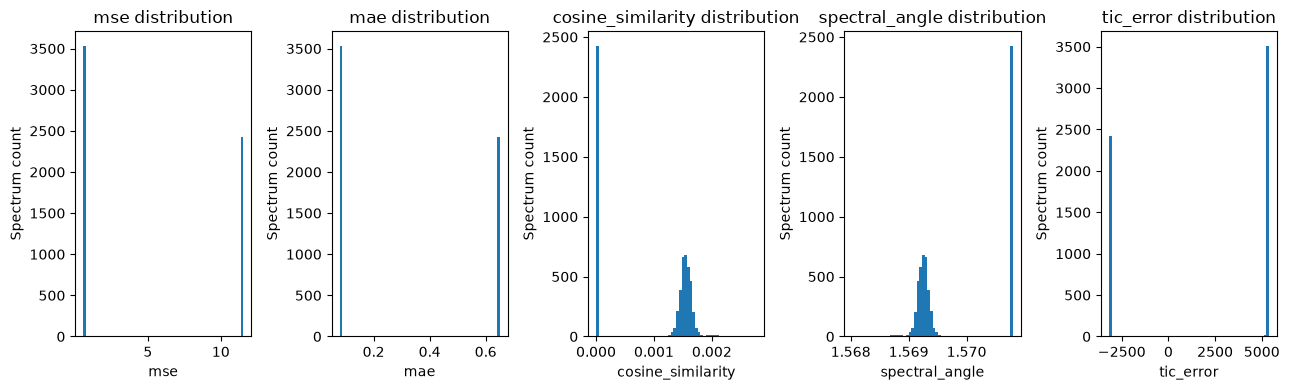

In [ ]:
figure, axes = plt.subplots(1, 5, figsize=(13, 4))
for axis, metric in zip(axes, ('mse', 'mae', 'cosine_similarity', 'spectral_angle', 'tic_error')):
    analysis.reconstruction.plot_distribution(metric=metric, bins=60, ax=axis)
figure.tight_layout()

False

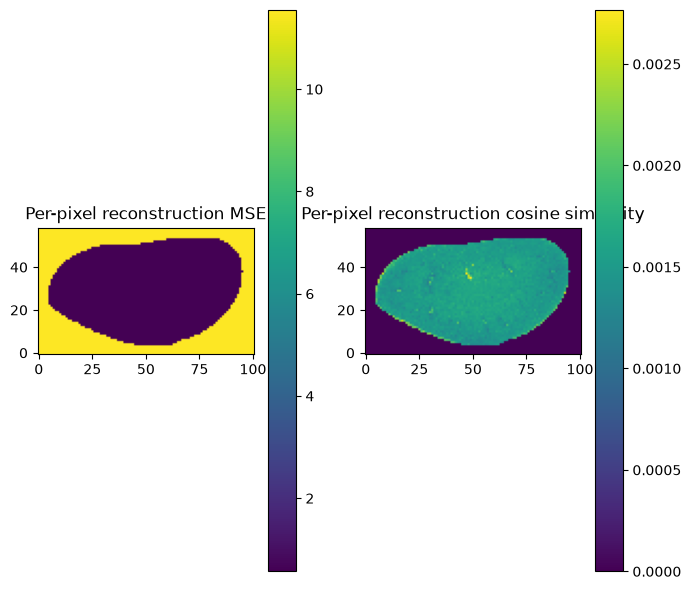

In [ ]:
from msi_autoencoder_wrapper.visualization.spatial import plot_spatial_image


mse_image = analysis.reconstruction.metric_image('mse')
cosine_image = analysis.reconstruction.metric_image('cosine_similarity')
figure, axes = plt.subplots(1, 2, figsize=(7, 6))
plot_spatial_image(mse_image.values, title='Per-pixel reconstruction MSE', ax=axes[0])
plot_spatial_image(cosine_image.values, title='Per-pixel reconstruction cosine similarity', ax=axes[1])
figure.tight_layout()


# The same metric can be restricted to spectra with or without annotations.
analysis.reconstruction.plot_error_images('mse', annotation_filter='annotated')
analysis.reconstruction.plot_error_images('mse', annotation_filter='unannotated')

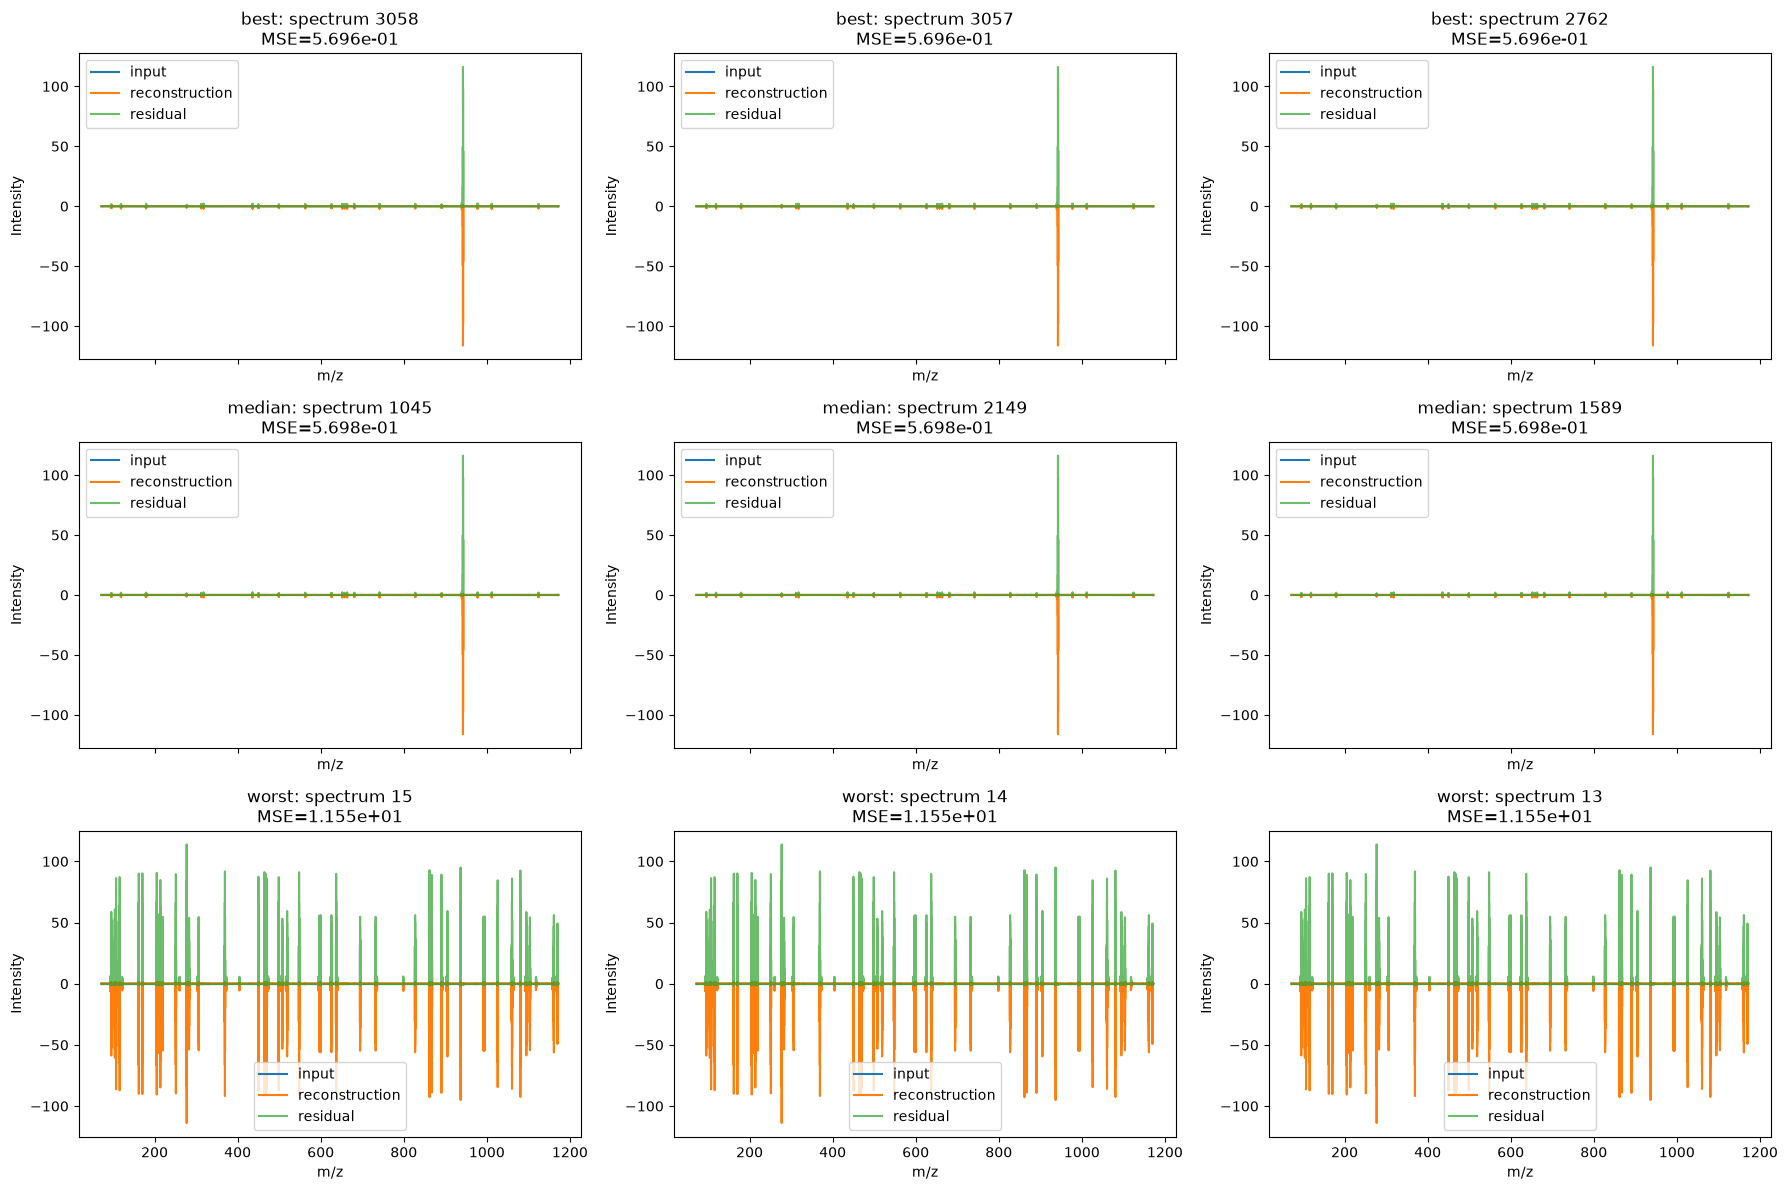

In [ ]:
mass_axis = wrapper.active_context.binner.GetXAxis()

selected_spectrum_figures = {
    selection: analysis.reconstruction.plot_selected_spectra(
        metric='mse',
        selection=selection,
        count=3,
        clip_reconstruction=True,
    )
    for selection in ('best', 'median', 'worst')
}
selected_spectrum_figures.keys()

#TODO - tutaj nie do końca rozumei co jest 5 
#TODO - pomysł jest dobry tylko trzeba zrobicto ianczej i bardziej wizualnie
#TODO - trzeba by to zrobić tak, że 
- dla kazdej metryki pokazuje rozkłady (te wąstate wykresy) na każdy m/z ale ponieważ jest gęsto trzeba by to odopwiendio kropkami i koloramiz zaznaczać,. wtedy wiedzielibyśm: jaki jst błąd i jaki jest rozkąłd (może być tak że kilka pikseli ma duży błąd itd,. wiecwiedizeli bśmy ja kto jest powanżenE)
- dla tych największych błędów, żeby zanzacży tea wartośći m/z pod nimi - żeby można było to póxneij sprwadzić 
- dla każdej metryki tak powinno sie móć to przetirweaoąc  



nie rozumiem czym jest tutaj bias 

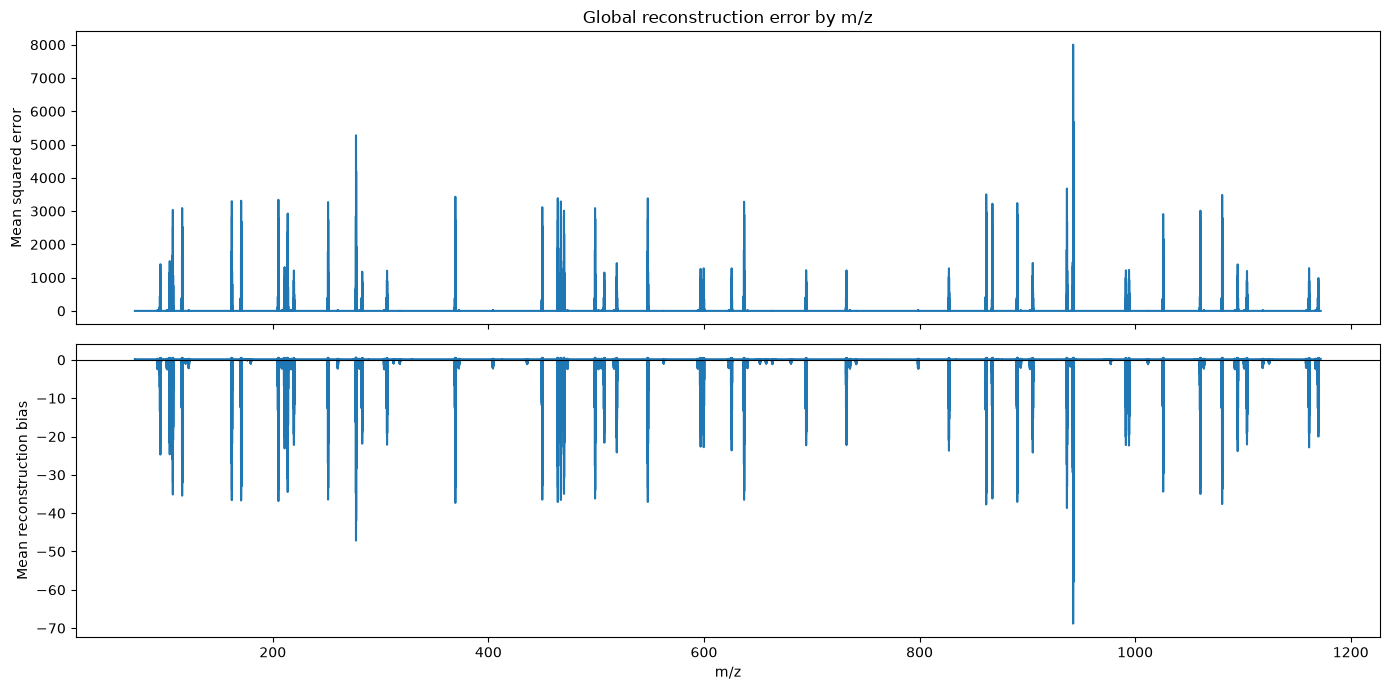

In [ ]:
feature_profiles = analysis.reconstruction.feature_distribution(
    metric='mse',
    quantiles=(0.05, 0.95),
    chunk_size=2048,
)
analysis.reconstruction.plot_feature_error_overview(
    metric='mse',
    quantiles=(0.05, 0.95),
    top_n=10,
)

## Ion-image reconstruction

The example ion is selected automatically as the binner position with the largest global reconstruction MSE. Change `selected_mz` to inspect a known molecule.



#TODO 
- powinno być że dostajemy znowu: 
  - kilka tych m/z - po pięc od najgorszych do najlepszydch

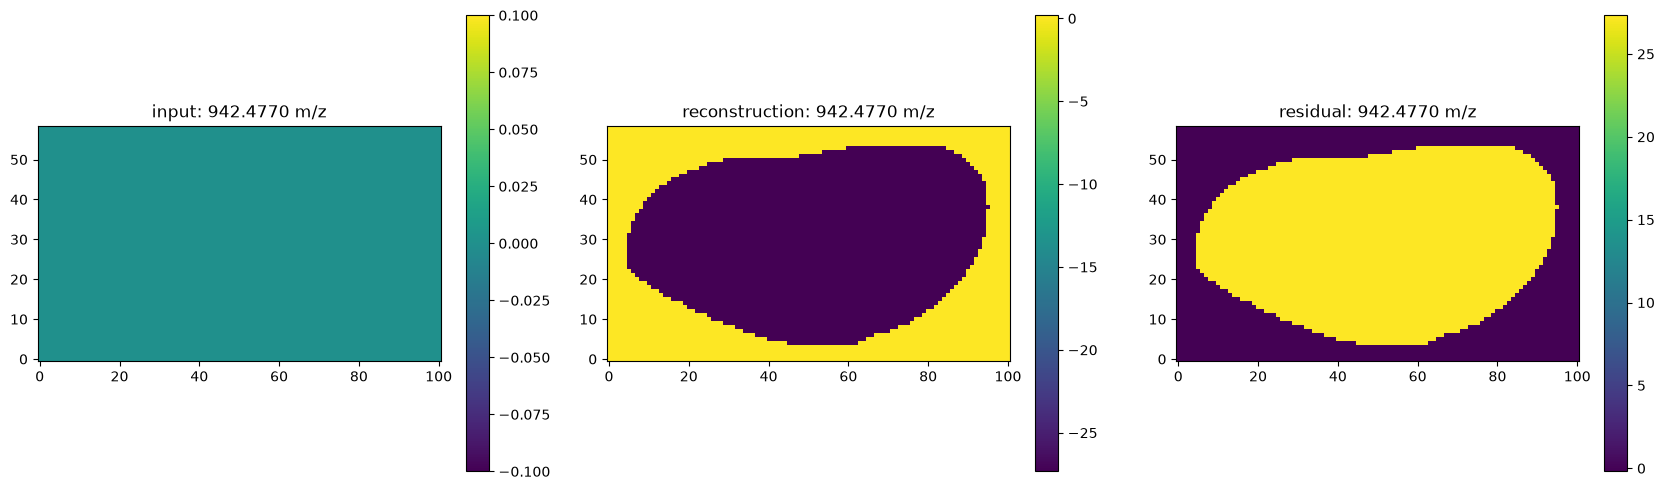

In [ ]:
worst_feature_index = int(np.argmax(prepared.feature_metrics['feature_mse']))
selected_mz = float(mass_axis[worst_feature_index])
ion_images = analysis.reconstruction.ion_images(
    mz=selected_mz,
    tolerance=0.02,
    aggregation='mean',
)

figure, axes = plt.subplots(1, 3, figsize=(17, 5))
for axis, (name, spatial_image) in zip(axes, ion_images.items()):
    plot_spatial_image(
        spatial_image.values,
        title=f'{name}: {selected_mz:.4f} m/z',
        ax=axis,
    )
figure.tight_layout()

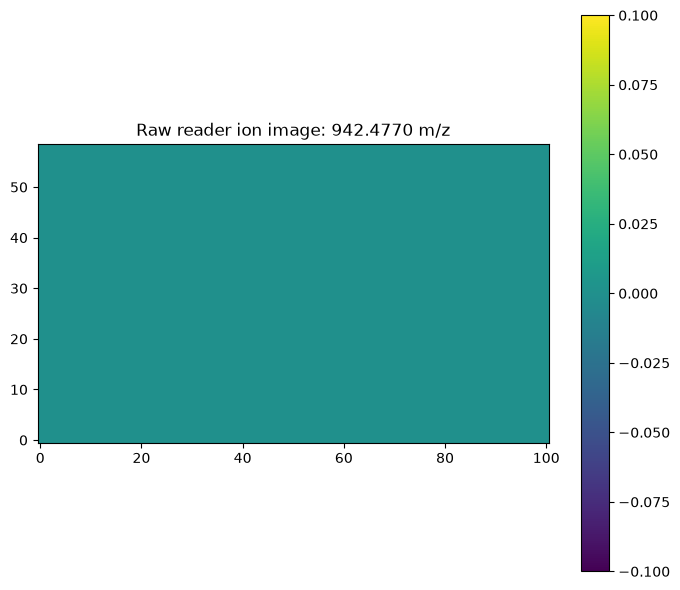

In [ ]:
raw_ion_image = analysis.reconstruction.raw_ion_image(
    mz=selected_mz,
    tolerance=0.02,
    aggregation='mean',
)
figure, axis = plt.subplots(figsize=(7, 6))
plot_spatial_image(
    raw_ion_image.values,
    title=f'Raw reader ion image: {selected_mz:.4f} m/z',
    ax=axis,
)
figure.tight_layout()

## Forward and inverse binner diagnostics

These reports are separate because forward binning and sparse inverse reconstruction are different lossy operations. A reproducible subset keeps this diagnostic quick.


#TODO 
- mse jest mał, ale ,moe by talze omteresopwaly by inne metryki jak chociażyby te związane z 

In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
diagnostic_ids = np.sort(rng.choice(
    len(wrapper.active_dataset),
    size=min(DIAGNOSTIC_SPECTRA, len(wrapper.active_dataset)),
    replace=False,
))
pd.DataFrame({
    'forward_binner': pd.Series(analysis.binning.forward_report(diagnostic_ids)),
    'inverse_binner': pd.Series(analysis.binning.inverse_report(diagnostic_ids)),
})

,forward_binner,inverse_binner
finite_fraction,1.0,NaN
max_tic_ratio,1.0,NaN
mean_mae,NaN,1.275864e-06
mean_mse,NaN,9.863631e-10
mean_tic_ratio,1.0,7.572255e-01
min_tic_ratio,1.0,NaN
spectrum_count,128.0,1.280000e+02


## Latent-space analysis

In [ ]:
latent_statistics = analysis.latent.statistics()
pd.DataFrame({
    'mean': latent_statistics['mean'],
    'std': latent_statistics['std'],
    'min': latent_statistics['min'],
    'max': latent_statistics['max'],
}).describe()

,mean,std,min,max
count,128.000000,128.000000,128.000000,128.000000
mean,-0.002516,0.721346,-1.095888,1.075666
std,0.735286,0.435366,0.735412,0.751288
min,-1.621865,0.031052,-3.369720,-0.763069
25%,-0.505810,0.307520,-1.532187,0.660068
50%,-0.004846,0.769589,-1.229715,1.177848
75%,0.498908,1.085820,-0.728125,1.474804
max,2.179147,1.717047,0.922455,3.604764


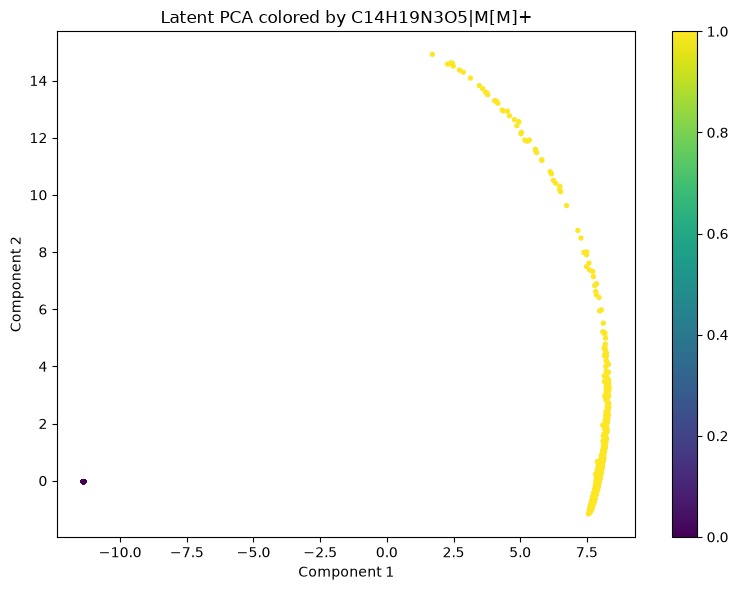

In [ ]:
molecule_targets = prepared.targets['molecule']
molecule_counts = molecule_targets.sum(axis=0)
display_class_index = int(np.argmax(molecule_counts))
class_mapping = wrapper.active_dataset.get_class_mappings()['molecule']
class_labels = {index: label for label, index in class_mapping.items()}
display_class_label = class_labels[display_class_index]

pca_projection = analysis.latent.project(
    method='pca',
    components=2,
    random_seed=RANDOM_SEED,
)
figure, axes = analysis.latent.plot_projection(
    method='pca',
    labels=molecule_targets[:, display_class_index],
    random_seed=RANDOM_SEED,
)
axes[0].set_title(f'Latent PCA colored by {display_class_label}')
figure.tight_layout()

NameError: name 'plot_projection' is not defined

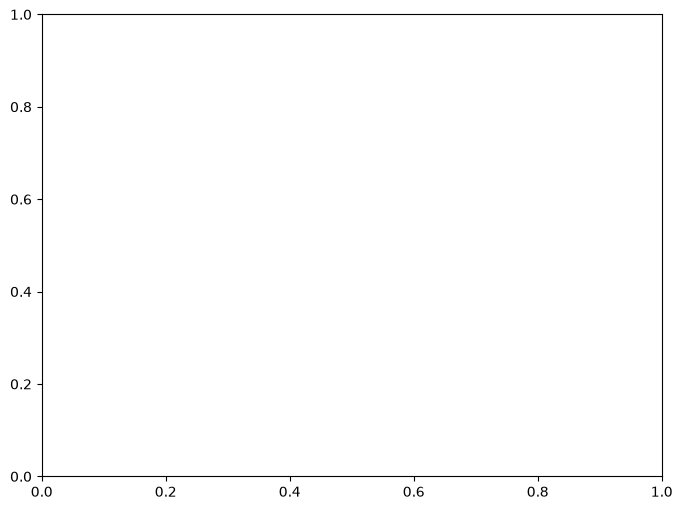

In [ ]:
if TSNE_ENABLED:
    tsne_projection = analysis.latent.project(
        method='tsne',
        components=2,
        random_seed=RANDOM_SEED,
        perplexity=30,
    )
    figure, axes = analysis.latent.plot_projection(
        method='tsne',
        labels=molecule_targets[:, display_class_index],
        random_seed=RANDOM_SEED,
        perplexity=30,
    )
    axes[0].set_title(f'Latent t-SNE colored by {display_class_label}')
    figure.tight_layout()
else:
    print('Set TSNE_ENABLED=True to run the slower t-SNE projection.')

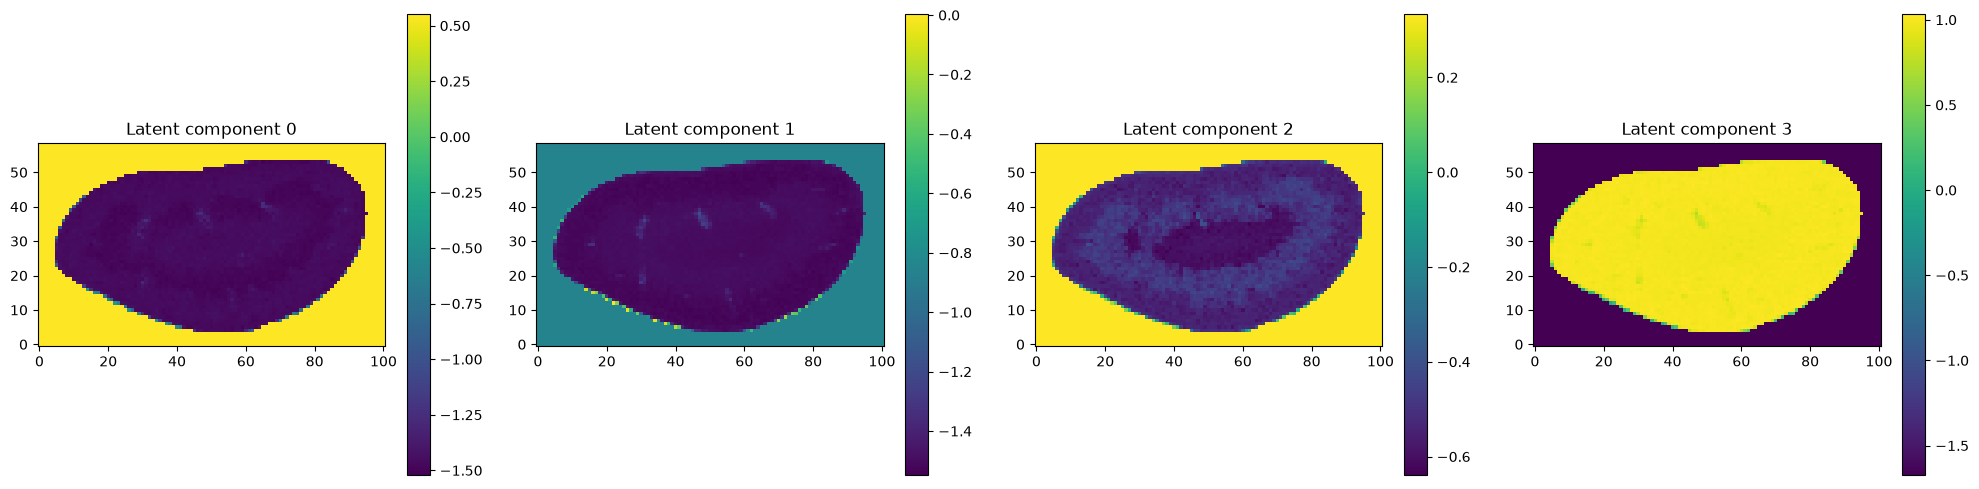

In [ ]:
latent_components = range(min(4, latents.shape[1]))
figure, axes = plt.subplots(1, len(latent_components), figsize=(5 * len(latent_components), 5))
axes = np.atleast_1d(axes)
for axis, component in zip(axes, latent_components):
    latent_image = analysis.latent.component_image(component)
    plot_spatial_image(
        latent_image.values,
        title=f'Latent component {component}',
        ax=axis,
    )
figure.tight_layout()

## Annotation-head evaluation

Head outputs are matched to dataset targets through each configured `target_field`. The current molecule head is evaluated as multi-label classification.

In [ ]:
head_metrics = analysis.heads.evaluate(threshold=0.5)
pd.DataFrame({
    head_name: {
        metric: value
        for metric, value in metrics.items()
        if np.isscalar(value)
    }
    for head_name, metrics in head_metrics.items()
}).T

,micro_f1,macro_f1,micro_precision,micro_recall,hamming_loss,average_precision
molecule_primary,0.999891,0.999891,0.999781,1.0,0.00013,1.0


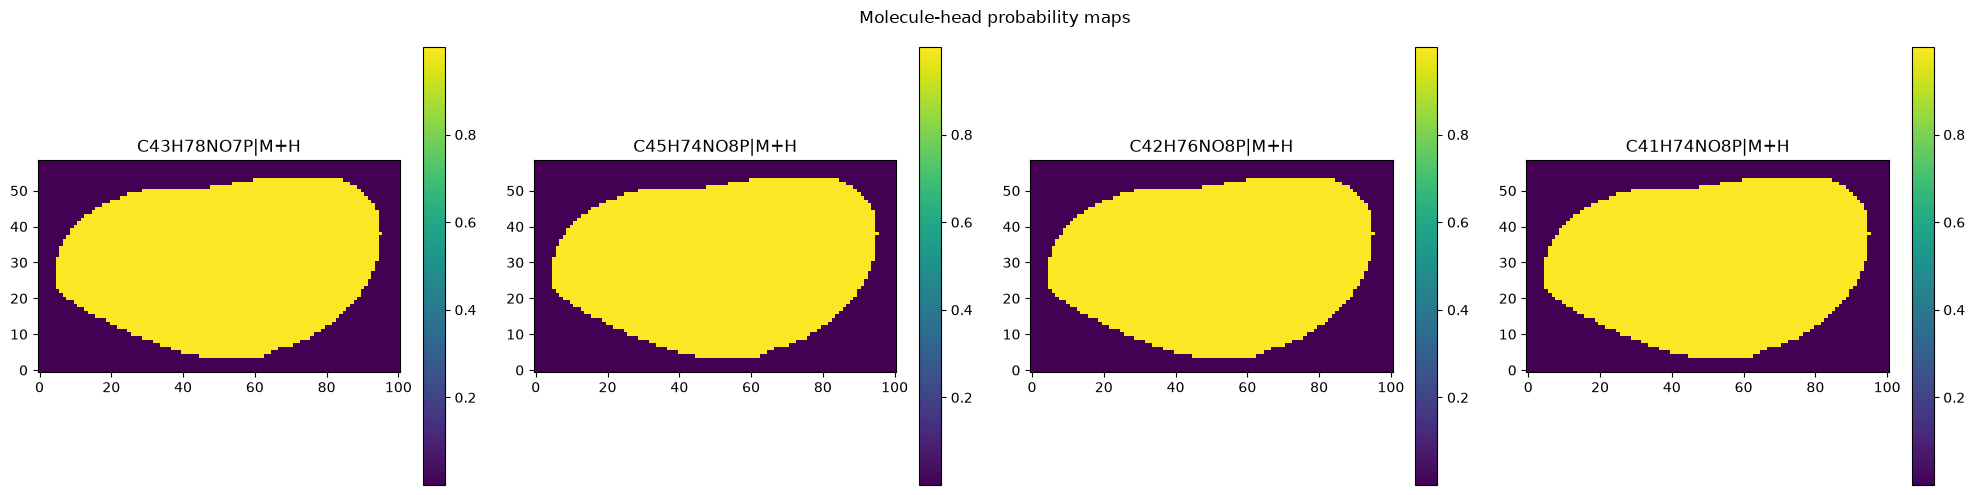

In [ ]:
head_name = 'molecule_primary'
display_classes = np.argsort(molecule_counts)[-4:][::-1]
figure, axes = plt.subplots(1, len(display_classes), figsize=(5 * len(display_classes), 5))
axes = np.atleast_1d(axes)
for axis, class_index in zip(axes, display_classes):
    probability_image = analysis.heads.probability_image(
        head_name=head_name,
        class_index=int(class_index),
    )
    plot_spatial_image(
        probability_image.values,
        title=class_labels[int(class_index)],
        ax=axis,
    )
figure.suptitle('Molecule-head probability maps')
figure.tight_layout()

In [ ]:
# Per-class metrics and spatial truth/probability/error panels.
class_metrics = pd.DataFrame(
    analysis.heads.class_metrics(head_name=head_name, threshold=0.5)
)
class_overviews = analysis.heads.plot_class_overview(
    head_name=head_name,
    class_indices=[int(index) for index in display_classes],
    threshold=0.5,
)
class_metrics

## Composed analysis groups

The following calls compose the atomic calculations and plots above. They reuse the prepared cache and the same global visualization theme; they do not run model inference again.

In [ ]:
reconstruction_overview = analysis.reconstruction.overview(
    metric='mse',
    annotation_filter='all',
    selected_count=3,
    top_features=10,
)
latent_overview = analysis.latent.overview(
    projection='pca',
    component_indices=range(min(4, latents.shape[1])),
    labels=molecule_targets[:, display_class_index],
)
head_overview = analysis.heads.overview(
    head_name=head_name,
    class_indices=[int(index) for index in display_classes],
    threshold=0.5,
)
binning_overview = analysis.binning.overview(diagnostic_ids)

{
    'reconstruction': tuple(reconstruction_overview),
    'latent': tuple(latent_overview),
    'heads': tuple(head_overview),
    'binning': tuple(binning_overview),
}

## Interactive ion-image viewer

The widget evaluates only the selected m/z window and uses the same input, reconstruction, and signed-residual image provider as the static analysis.

In [ ]:
ion_viewer = analysis.reconstruction.ion_viewer(
    tolerance=0.02,
    aggregation='mean',
)
initial_ion_index = int(np.argmin(np.abs(mass_axis - selected_mz)))
ion_viewer.widget(initial_index=initial_ion_index)